# Отчёт по экспериментам с оптимизацией гиперпараметров

## Проделанная работа

В рамках экспериментов была выполнена следующая работа:

1. **RandomizedSearch для Logistic Regression** (500 итераций, 5 фолдов) — подбор параметров: C, penalty, l1_ratio, tol, max_iter, class_weight, fit_intercept
2. **RandomizedSearch для Decision Tree** (500 итераций, 5 фолдов) — подбор: max_depth, min_samples_split, min_samples_leaf, criterion, max_features, ccp_alpha и др.
3. **RandomizedSearch для Random Forest** (30 итераций, 3 фолда) — подбор: n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features, criterion, bootstrap
4. **Ручная настройка Random Forest** на основе лучших параметров

## Результаты моделей (валидационная выборка)

| Модель | Accuracy | F1 | Precision | Recall | ROC-AUC |
|--------|----------|-----|-----------|--------|---------|
| **Logistic Regression (оптимизир.)** | 0.674 | 0.331 | 0.217 | 0.693 | 0.749 |
| **Decision Tree (оптимизир.)** | 0.685 | 0.319 | 0.213 | 0.635 | 0.726 |
| **Random Forest (оптимизир.)** | 0.814 | 0.365 | 0.303 | 0.459 | 0.750 |
| **Random Forest (улучшенный)** | 0.814 | 0.364 | 0.302 | 0.458 | 0.752 |

## Сравнение с бейзлайнами

| Модель | Бейзлайн F1 | Оптимизир. F1 | Изменение |
|--------|-------------|---------------|-----------|
| **Logistic Regression** | 0.331 | 0.331 | **0.000** |
| **Decision Tree** | 0.289 | 0.319 | **+0.030** |
| **Random Forest** | 0.353 | 0.365 | **+0.012** |

## Ключевые выводы

**Ощутимого прироста качества не получено**

| Модель | Проблема |
|--------|----------|
| **Logistic Regression** | Низкий Precision (~22%) при высоком Recall (~69%) — модель слишком агрессивно предсказывает дефолты |
| **Decision Tree** | Precision ещё ниже (~19-21%), Recall ~63% — дерево явно переобучено даже с ограничениями |
| **Random Forest** | Лучший Precision (~30%), но низкий Recall (~46%) — модель слишком консервативна |

## Сохранённые артефакты

| Тип | Путь |
|-----|------|
| Метрики моделей | `../artifacts/Experiments/runsExp.csv` |
| Матрицы ошибок | `../artifacts/Experiments/figures` |
| ROC-кривые | `../artifacts/Experiments/figures` |
| PR-кривые | `../artifacts/Experiments/figures` |
| Конфиги моделей | `../artifacts/Experiments/configs/experiments_config.json` |



In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from scipy.stats import uniform, loguniform, randint

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTETomek

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    confusion_matrix
)

In [2]:
df = pd.read_csv("../data/PROCESSED/LoanDefaultPredictionDatasetPROC.csv")
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,HasMortgage_Yes,HasDependents_No,HasDependents_Yes,LoanPurpose_Auto,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_No,HasCoSigner_Yes
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,1,0,1,0,0,0,0,1,0,1
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,1,0,0,0,0,0,1,0,1
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,1,0,1,1,0,0,0,0,1,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,1,0,0,1,0,0,0,1,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,0,0,1,1,0,0,0,0,1,0


In [3]:
X = df.drop("Default", axis=1)
y = df["Default"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Размеры выборок:")
print("train:", X_train.shape)
print("val:", X_val.shape)
print("test:", X_test.shape)

print("\nРаспределение классов (train):")
print(y_train.value_counts(normalize=True))
print("\nРаспределение классов (val):")
print(y_val.value_counts(normalize=True))
print("\nРаспределение классов (test):")
print(y_test.value_counts(normalize=True))

Размеры выборок:
train: (178742, 31)
val: (38302, 31)
test: (38303, 31)

Распределение классов (train):
Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

Распределение классов (val):
Default
0    0.88387
1    0.11613
Name: proportion, dtype: float64

Распределение классов (test):
Default
0    0.883873
1    0.116127
Name: proportion, dtype: float64


In [7]:
expLogReg = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(
                penalty="l2",
                C=1.0,         
                solver="saga", 
                random_state=42,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-4,
            ),
        ),
    ]
)

# Настроим сетку по параметру C (сила регуляризации)
param_grid = {
    # Сила регуляризации
    "logreg__C": loguniform(0.01, 100),
    
    # Тип регуляризации (L1, L2, ElasticNet)
    "logreg__penalty": ["l1", "l2", "elasticnet"],
    
    # Соотношение L1/L2 для elasticnet (только при penalty='elasticnet')
    "logreg__l1_ratio": uniform(0, 1),
        
    # Порог сходимости
    "logreg__tol": loguniform(1e-5, 1e-3),
    
    # Максимальное число итераций (можно увеличить для сходимости при малых C)
    "logreg__max_iter": randint(1000, 5001),
    
    # Веса классов (разные стратегии)
    "logreg__class_weight": ["balanced", None],
    
    # Использовать ли intercept
    "logreg__fit_intercept": [True, False],
}

random_search = RandomizedSearchCV(
    estimator=expLogReg,
    param_distributions=param_grid,
    n_iter=500,
    scoring="f1",    # можно поменять на f1, recall и т.д.
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Лучшие параметры:", random_search.best_params_)
print("Лучший F1 (по CV):", random_search.best_score_)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits


d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1172: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


Лучшие параметры: {'logreg__C': 0.016137130466116877, 'logreg__class_weight': 'balanced', 'logreg__fit_intercept': True, 'logreg__l1_ratio': 0.2013637821359744, 'logreg__max_iter': 3438, 'logreg__penalty': 'l1', 'logreg__tol': 2.1350728935360847e-05}
Лучший F1 (по CV): 0.32889544164800644


In [9]:
random_search = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(
                penalty="l1",
                C=0.016137130466116877,         
                solver="saga", 
                random_state=42,
                class_weight="balanced",
                max_iter=3438,
                tol=2.1350728935360847e-05,
                fit_intercept=True,
                l1_ratio=0.2013637821359744,
            ),
        ),
    ]
)

random_search.fit(X_train, y_train)

d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1172: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(C=0.016137130466116877,
                                    class_weight='balanced',
                                    l1_ratio=0.2013637821359744, max_iter=3438,
                                    penalty='l1', random_state=42,
                                    solver='saga',
                                    tol=2.1350728935360847e-05))])

In [ ]:
expDecisionTree = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

param_distributions_tree = {
    # Максимальная глубина дерева
    "max_depth": randint(3, 30),
    
    # Минимальное количество для разбиения узла
    "min_samples_split": randint(20, 200),
    
    # Минимальное количество в листе
    "min_samples_leaf": randint(10, 100),
    
    # Критерий качества разбиения
    "criterion": ["gini", "entropy", "log_loss"],
    
    # Максимальное количество признаков для поиска лучшего разбиения
    "max_features": ["sqrt", "log2", None, 0.3, 0.5, 0.7],
    
    # Минимальное взвешенное количество в листе
    "min_weight_fraction_leaf": uniform(0, 0.05),
    
    # Минимальное уменьшение примеси для разбиения
    "min_impurity_decrease": [0.0, 1e-7, 1e-6, 1e-5, 1e-4],
    
    # Параметр для обрезки (cost complexity pruning)
    "ccp_alpha": [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05],
    
    # Стратегия разбиения
    "splitter": ["best", "random"],
}
random_search_tree = RandomizedSearchCV(
    estimator=expDecisionTree,
    param_distributions=param_distributions_tree,
    n_iter=500,  # количество комбинаций
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    return_train_score=True,
    verbose=2
)
random_search_tree.fit(X_train, y_train)

print("Лучшие параметры:", random_search_tree.best_params_)
print("Лучший F1 (по CV):", random_search_tree.best_score_)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV] END ccp_alpha=0.005, criterion=gini, max_depth=17, max_features=None, min_impurity_decrease=0.0001, min_samples_leaf=30, min_samples_split=122, min_weight_fraction_leaf=0.02229163764267956, splitter=best; total time=   0.6s
[CV] END ccp_alpha=0.005, criterion=gini, max_depth=17, max_features=None, min_impurity_decrease=0.0001, min_samples_leaf=30, min_samples_split=122, min_weight_fraction_leaf=0.02229163764267956, splitter=best; total time=   0.6s
[CV] END ccp_alpha=0.005, criterion=gini, max_depth=17, max_features=None, min_impurity_decrease=0.0001, min_samples_leaf=30, min_samples_split=122, min_weight_fraction_leaf=0.02229163764267956, splitter=best; total time=   0.5s
[CV] END ccp_alpha=0.005, criterion=gini, max_depth=17, max_features=None, min_impurity_decrease=0.0001, min_samples_leaf=30, min_samples_split=122, min_weight_fraction_leaf=0.02229163764267956, splitter=best; total time=   0.5s
[CV] END ccp_alpha=0

In [ ]:
randomForest = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
)

param_distributions_rf = {
    # Количество деревьев
    "n_estimators": randint(100, 300),
    
    # Максимальная глубина
    "max_depth": [15, 30, None],
    
    # Минимальное количество для разбиения
    "min_samples_split": randint(10, 200),
    
    # Минимальное количество в листе
    "min_samples_leaf": randint(5, 100),
    
    # Количество признаков для поиска лучшего разбиения
    "max_features": ["sqrt", "log2", None, 0.3, 0.5, 0.7],
    
    # Критерий качества
    "criterion": ["gini", "entropy"],
    
    # Bootstrap (нужно ли)
    "bootstrap": [True, False],
}

random_search_rf = RandomizedSearchCV(
    estimator=randomForest,
    param_distributions=param_distributions_rf,
    n_iter=30,  # 30 комбинаций
    scoring="f1",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),  
    random_state=42, 
    verbose=2,
    return_train_score=True
)

random_search_rf.fit(X_train, y_train)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END bootstrap=True, criterion=entropy, max_depth=15, max_features=None, min_samples_leaf=76, min_samples_split=198, n_estimators=120; total time= 1.6min
[CV] END bootstrap=True, criterion=entropy, max_depth=15, max_features=None, min_samples_leaf=76, min_samples_split=198, n_estimators=120; total time= 1.6min
[CV] END bootstrap=True, criterion=entropy, max_depth=15, max_features=None, min_samples_leaf=76, min_samples_split=198, n_estimators=120; total time= 1.6min
[CV] END bootstrap=True, criterion=entropy, max_depth=None, max_features=None, min_samples_leaf=79, min_samples_split=97, n_estimators=216; total time= 2.7min
[CV] END bootstrap=True, criterion=entropy, max_depth=None, max_features=None, min_samples_leaf=79, min_samples_split=97, n_estimators=216; total time= 3.3min
[CV] END bootstrap=True, criterion=entropy, max_depth=None, max_features=None, min_samples_leaf=79, min_samples_split=97, n_estimators=216; total t

NameError: name 'random_search_tree' is not defined

In [5]:
print("Лучшие параметры:", random_search_rf.best_params_)
print("Лучший F1 (по CV):", random_search_rf.best_score_)

Лучшие параметры: {'bootstrap': False, 'criterion': 'gini', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 37, 'n_estimators': 127}
Лучший F1 (по CV): 0.3538293790080203


In [6]:
random_search_tree =  DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    ccp_alpha=0.0001, 
    criterion='entropy',
    max_depth=8, 
    max_features=0.5, 
    min_impurity_decrease=1e-05, 
    min_samples_leaf=57, 
    min_samples_split=47, 
    min_weight_fraction_leaf=0.0038065429745150095, 
    splitter='best'
)

random_search_tree.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0001, class_weight='balanced',
                       criterion='entropy', max_depth=8, max_features=0.5,
                       min_impurity_decrease=1e-05, min_samples_leaf=57,
                       min_samples_split=47,
                       min_weight_fraction_leaf=0.0038065429745150095,
                       random_state=42)

In [7]:
beterRandomForest = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    bootstrap=False, 
    criterion='gini', 
    max_depth=30, 
    max_features='sqrt', 
    min_samples_leaf=10, 
    min_samples_split=37, 
    n_estimators=500
)

beterRandomForest.fit(X_train, y_train)

RandomForestClassifier(bootstrap=False, class_weight='balanced', max_depth=30,
                       min_samples_leaf=10, min_samples_split=37,
                       n_estimators=500, random_state=42)

In [10]:
def compute_metrics(y_true, y_pred, y_proba=None):
    methrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
        "Precision": float(precision_score(y_val, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_val, y_pred, zero_division=0)),
    }
    if y_proba is None:
        methrics["roc_auc"] = None
    else:
        try:
            methrics["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            methrics["roc_auc"] = None
    return methrics

def evaluate_on_test(model, X_test, y_test, label):
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    methrics = compute_metrics(y_test, pred, proba)
    methrics["model"] = label
    return methrics

runsExp = []

runsExp.append(evaluate_on_test(random_search, X_val, y_val, "LogReg"))
runsExp.append(evaluate_on_test(random_search_tree, X_val, y_val, "DecisionTree"))
runsExp.append(evaluate_on_test(random_search_rf.best_estimator_, X_val, y_val, "RandomForest"))
runsExp.append(evaluate_on_test(beterRandomForest, X_val, y_val, "BeterRandomForest"))

for i in runsExp:
    print(i)

print("LogReg", classification_report(y_val,  random_search.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')
print("DecisionTree", classification_report(y_val,  random_search_tree.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')
print("RandomForest", classification_report(y_val,  random_search_rf.best_estimator_.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')
print("BetRandomForest", classification_report(y_val,  beterRandomForest.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')



{'accuracy': 0.6741162341392094, 'f1': 0.3305084745762712, 'Precision': 0.21703296703296704, 'Recall': 0.6926708633093526, 'roc_auc': 0.7485400437256386, 'model': 'LogReg'}
{'accuracy': 0.6848206359981202, 'f1': 0.3187358916478555, 'Precision': 0.21277878239903555, 'Recall': 0.6348920863309353, 'roc_auc': 0.7256722974990363, 'model': 'DecisionTree'}
{'accuracy': 0.8144744399770247, 'f1': 0.3650822015725518, 'Precision': 0.3029359430604982, 'Recall': 0.45930755395683454, 'roc_auc': 0.7499127986852557, 'model': 'RandomForest'}
{'accuracy': 0.8141350321132056, 'f1': 0.3637501117168648, 'Precision': 0.3018839934727785, 'Recall': 0.4575089928057554, 'roc_auc': 0.7515260329693356, 'model': 'BeterRandomForest'}
LogReg
              precision    recall  f1-score   support

   Не дефолт       0.94      0.67      0.78     33854
      Дефолт       0.22      0.69      0.33      4448

    accuracy                           0.67     38302
   macro avg       0.58      0.68      0.56     38302
weighte

In [11]:
print("RandomForest", classification_report(y_val,  random_search_rf.best_estimator_.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')
print("BetRandomForest", classification_report(y_val,  beterRandomForest.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')

RandomForest
              precision    recall  f1-score   support

   Не дефолт       0.92      0.86      0.89     33854
      Дефолт       0.30      0.46      0.37      4448

    accuracy                           0.81     38302
   macro avg       0.61      0.66      0.63     38302
weighted avg       0.85      0.81      0.83     38302

BetRandomForest
              precision    recall  f1-score   support

   Не дефолт       0.92      0.86      0.89     33854
      Дефолт       0.30      0.46      0.36      4448

    accuracy                           0.81     38302
   macro avg       0.61      0.66      0.63     38302
weighted avg       0.85      0.81      0.83     38302



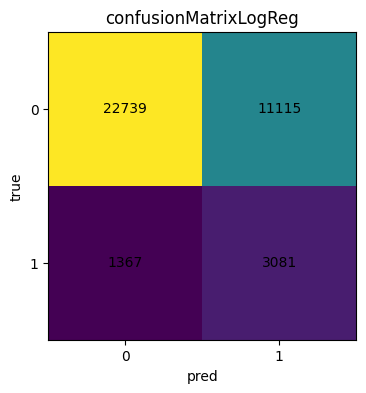

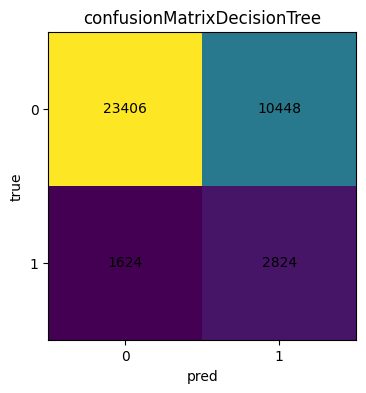

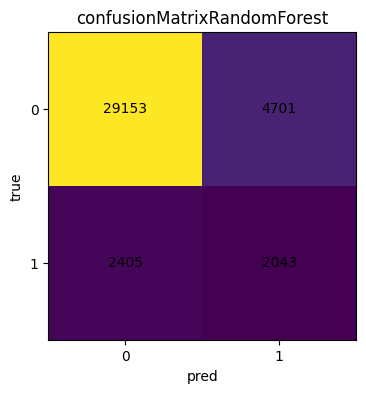

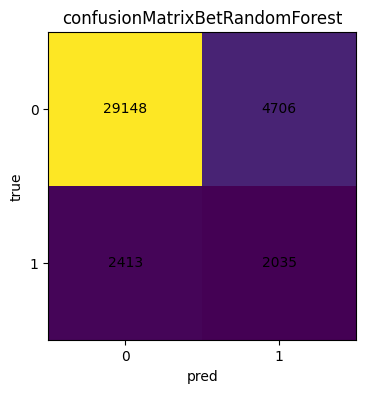

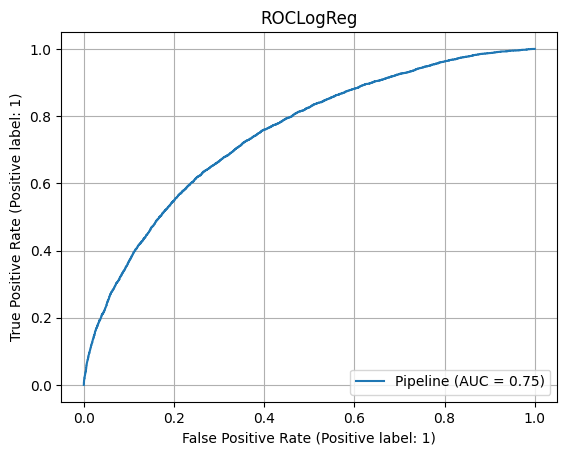

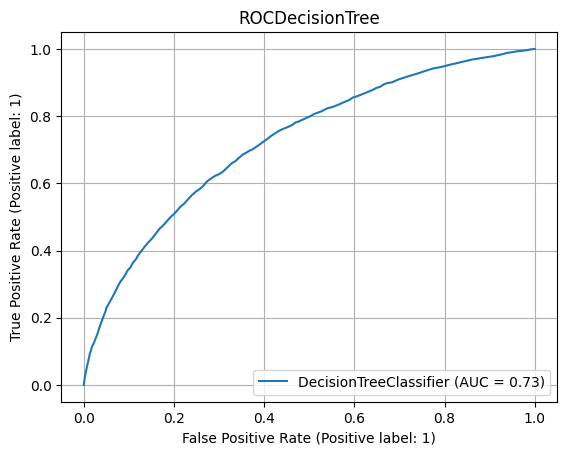

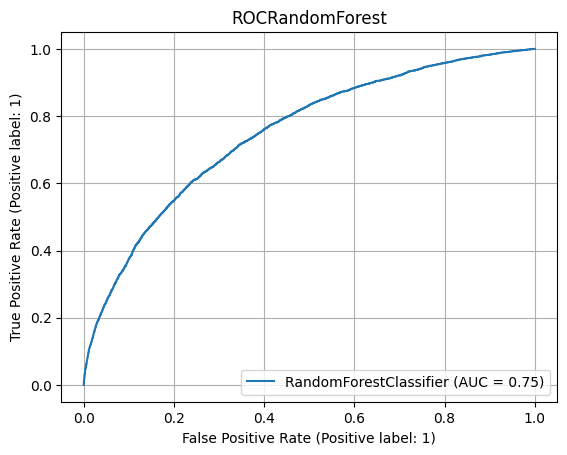

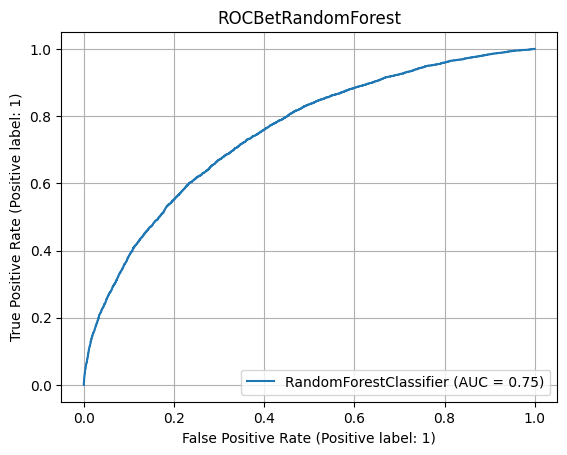

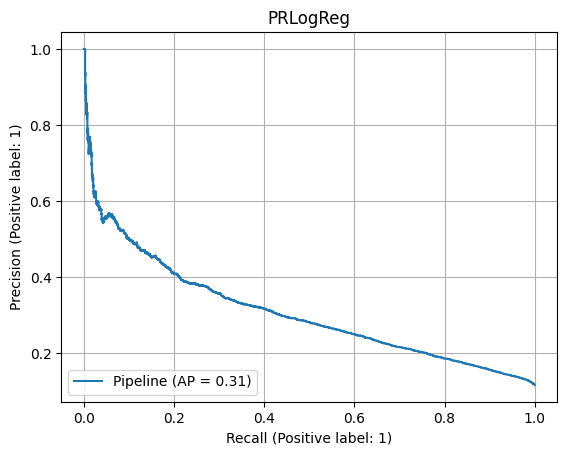

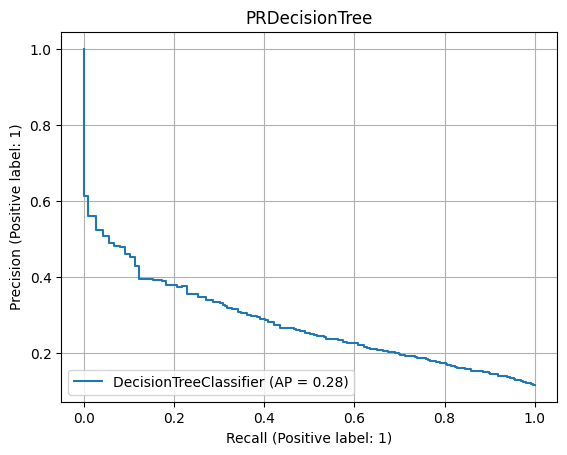

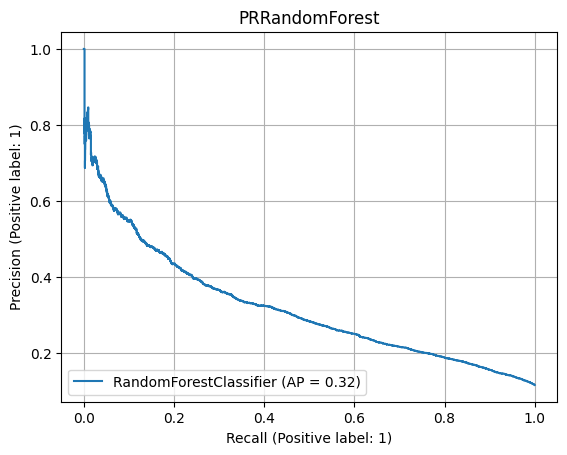

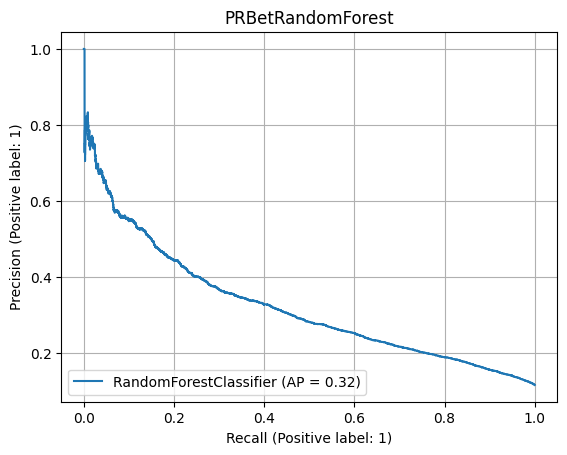

In [12]:
#рисует матрицу ошибок
def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    pth = f"../artifacts/Experiments/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

#рисует roc кривую
def plot_roc(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.grid(True)
    pth = f"../artifacts/Experiments/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

def plot_prd(model, X_test, y_test, title):
    if not hasattr(model, "predict_proba"):
        print("PrecisionRecallDisplay: модель не поддерживает predict_proba")
        return
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.grid(True)
    pth = f"../artifacts/Experiments/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

plot_confusion(y_val, random_search.predict(X_val), "confusionMatrixLogReg")
plot_confusion(y_val, random_search_tree.predict(X_val), "confusionMatrixDecisionTree")
plot_confusion(y_val, random_search_rf.best_estimator_.predict(X_val), "confusionMatrixRandomForest")
plot_confusion(y_val, beterRandomForest.predict(X_val), "confusionMatrixBetRandomForest")

plot_roc(random_search, X_val, y_val, "ROCLogReg")
plot_roc(random_search_tree, X_val, y_val, "ROCDecisionTree")
plot_roc(random_search_rf.best_estimator_, X_val, y_val, "ROCRandomForest")
plot_roc(beterRandomForest, X_val, y_val, "ROCBetRandomForest")

plot_prd(random_search, X_val, y_val, "PRLogReg")
plot_prd(random_search_tree, X_val, y_val, "PRDecisionTree")
plot_prd(random_search_rf.best_estimator_, X_val, y_val, "PRRandomForest")
plot_prd(beterRandomForest, X_val, y_val, "PRBetRandomForest")


In [13]:
def save_metrics_to_csv(metrics_list, filepath):
    # Создаём DataFrame из списка
    df_metrics = pd.DataFrame(metrics_list)
    
    # Сортируем по ROC-AUC (опционально)
    df_metrics = df_metrics.sort_values('f1', ascending=False)
        
    # Сохраняем в CSV
    df_metrics.to_csv(filepath, index=False)
    print("ГОТОВО!")

save_metrics_to_csv(runsExp, "../artifacts/Experiments/runsExp.csv")

ГОТОВО!


In [14]:
EXPERIMENT_CONFIG = {
    "data_path": "../data/PROCESSED/LoanDefaultPredictionDatasetPROC.csv",
    "target_column": "Default",
    "random_state": 42,
    "test_size": 0.3,
    "val_size": 0.5,  
    "stratify": True
}

# Конфигурация Logistic Regression (оптимизированная)
LOGREG_OPTIMIZED_CONFIG = {
    "model_name": "LogisticRegressionOptimized",
    "is_pipeline": True,
    "scaler": {
        "name": "StandardScaler",
        "params": {
            "copy": True,
            "with_mean": True,
            "with_std": True
        }
    },
    "logreg": {
        "penalty": "l1",
        "C": 0.016137130466116877,
        "solver": "saga",
        "random_state": 42,
        "class_weight": "balanced",
        "max_iter": 3438,
        "tol": 2.1350728935360847e-05,
        "fit_intercept": True,
        "l1_ratio": 0.2013637821359744
    }
}

# Конфигурация Decision Tree (оптимизированная)
DECISION_TREE_OPTIMIZED_CONFIG = {
    "model_name": "DecisionTreeOptimized",
    "is_pipeline": False,
    "params": {
        "random_state": 42,
        "class_weight": "balanced",
        "ccp_alpha": 0.0001,
        "criterion": "entropy",
        "max_depth": 8,
        "max_features": 0.5,
        "min_impurity_decrease": 1e-05,
        "min_samples_leaf": 57,
        "min_samples_split": 47,
        "min_weight_fraction_leaf": 0.0038065429745150095,
        "splitter": "best"
    }
}

# Конфигурация Random Forest (оптимизированная - из RandomizedSearch)
RANDOM_FOREST_OPTIMIZED_CONFIG = {
    "model_name": "RandomForestOptimized",
    "is_pipeline": False,
    "params": {
        "random_state": 42,
        "class_weight": "balanced",
        "bootstrap": False,
        "criterion": "gini",
        "max_depth": 30,
        "max_features": "sqrt",
        "min_samples_leaf": 10,
        "min_samples_split": 37,
        "n_estimators": 127
    }
}

# Конфигурация Random Forest (улучшенная - ручная настройка)
RANDOM_FOREST_BETTER_CONFIG = {
    "model_name": "RandomForestBetter",
    "is_pipeline": False,
    "params": {
        "random_state": 42,
        "class_weight": "balanced",
        "bootstrap": False,
        "criterion": "gini",
        "max_depth": 30,
        "max_features": "sqrt",
        "min_samples_leaf": 10,
        "min_samples_split": 37,
        "n_estimators": 500
    }
}

# Параметры для Random Search (использовались для поиска)
RANDOM_SEARCH_PARAMS = {
    "logreg": {
        "n_iter": 500,
        "cv": 5,
        "scoring": "f1",
        "param_distributions": {
            "logreg__C": "loguniform(0.01, 100)",
            "logreg__penalty": ["l1", "l2", "elasticnet"],
            "logreg__l1_ratio": "uniform(0, 1)",
            "logreg__tol": "loguniform(1e-5, 1e-3)",
            "logreg__max_iter": "randint(1000, 5001)",
            "logreg__class_weight": ["balanced", None],
            "logreg__fit_intercept": [True, False]
        }
    },
    "decision_tree": {
        "n_iter": 500,
        "cv": 5,
        "scoring": "f1",
        "param_distributions": {
            "max_depth": "randint(3, 30)",
            "min_samples_split": "randint(20, 200)",
            "min_samples_leaf": "randint(10, 100)",
            "criterion": ["gini", "entropy", "log_loss"],
            "max_features": ["sqrt", "log2", None, 0.3, 0.5, 0.7],
            "min_weight_fraction_leaf": "uniform(0, 0.05)",
            "min_impurity_decrease": [0.0, 1e-7, 1e-6, 1e-5, 1e-4],
            "ccp_alpha": [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05],
            "splitter": ["best", "random"]
        }
    },
    "random_forest": {
        "n_iter": 30,
        "cv": 3,
        "scoring": "f1",
        "param_distributions": {
            "n_estimators": "randint(100, 300)",
            "max_depth": [15, 30, None],
            "min_samples_split": "randint(10, 200)",
            "min_samples_leaf": "randint(5, 100)",
            "max_features": ["sqrt", "log2", None, 0.3, 0.5, 0.7],
            "criterion": ["gini", "entropy"],
            "bootstrap": [True, False]
        }
    }
}

# Сводный словарь со всеми конфигурациями экспериментов
ALL_EXPERIMENTS_CONFIG = {
    "experiment": EXPERIMENT_CONFIG,
    "random_search_params": RANDOM_SEARCH_PARAMS,
    "models": {
        "logreg_optimized": LOGREG_OPTIMIZED_CONFIG,
        "decision_tree_optimized": DECISION_TREE_OPTIMIZED_CONFIG,
        "random_forest_optimized": RANDOM_FOREST_OPTIMIZED_CONFIG,
        "random_forest_better": RANDOM_FOREST_BETTER_CONFIG
    }
}

# Сохраняем общий конфиг
with open("../configs/experiments_config.json", "w") as f:
    json.dump(ALL_EXPERIMENTS_CONFIG, f, indent=4)